# Prediccion del precio promedio del aguacate usando regresion MLP

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)
from sklearn.preprocessing import StandardScaler

### 1. importamos los datos procesados y normalizados y los dividimos en train y test

Tambien añadimos el mes de cada entrada para tener en cuenta la temporalidad

In [ ]:
df_avocado = pd.read_csv("../data/clean_avocado.csv")

df_avocado["Date"] = pd.to_datetime(df_avocado["Date"])
df_avocado["Month"] = df_avocado["Date"].dt.month
# Variables predictoras (X) y objetivo (y)
X = df_avocado.drop(columns=['AveragePrice', "Date"])
y = df_avocado['AveragePrice']  
feature_names = X.columns

# Dividir datos en entrenamiento y prueba (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)




2.8806244112353547

### 2. Entrenamos a nuestro modelo

In [102]:
mlp_reg = MLPRegressor(
    hidden_layer_sizes=(200,100, 50), activation='relu', solver='adam',
    learning_rate_init=0.001, alpha=0.001, max_iter=2000,
    early_stopping=True, verbose=True
)
mlp_reg.fit(X_train, y_train)

Iteration 1, loss = 1111.30261647
Validation score: -4.447762
Iteration 2, loss = 0.62241543
Validation score: 0.284545
Iteration 3, loss = 0.35726231
Validation score: 0.389952
Iteration 4, loss = 0.30790698
Validation score: 0.395710
Iteration 5, loss = 0.29778845
Validation score: 0.393535
Iteration 6, loss = 0.29775921
Validation score: 0.380392
Iteration 7, loss = 0.28232387
Validation score: 0.278592
Iteration 8, loss = 0.30492631
Validation score: 0.460764
Iteration 9, loss = 0.25830153
Validation score: 0.473751
Iteration 10, loss = 0.25838027
Validation score: 0.402393
Iteration 11, loss = 0.24374480
Validation score: 0.548911
Iteration 12, loss = 0.22015117
Validation score: 0.570600
Iteration 13, loss = 0.21929861
Validation score: 0.564149
Iteration 14, loss = 0.21392344
Validation score: 0.560696
Iteration 15, loss = 0.20425127
Validation score: 0.557038
Iteration 16, loss = 0.20236914
Validation score: 0.615045
Iteration 17, loss = 0.19091769
Validation score: 0.587404
It

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(200, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


### 3. Resultados del entrenamiento

In [106]:
y_pred_mlp = mlp_reg.predict(X_test)
MSE_MLP = mean_squared_error(y_test, y_pred_mlp)
R2_MLP = r2_score(y_test, y_pred_mlp)
print(f"MLP Regressor MSE: {mean_squared_error(y_test, y_pred_mlp):.3f}")
print(f"MLP Regressor R2: {r2_score(y_test, y_pred_mlp):.3f}")

MLP Regressor MSE: 0.337
MLP Regressor R2: 0.670


Podemos observar un R² de 0.64 indicandos que este modelo no es el mas indicado para predecir este dataset.

### 4. Graficos y analisis

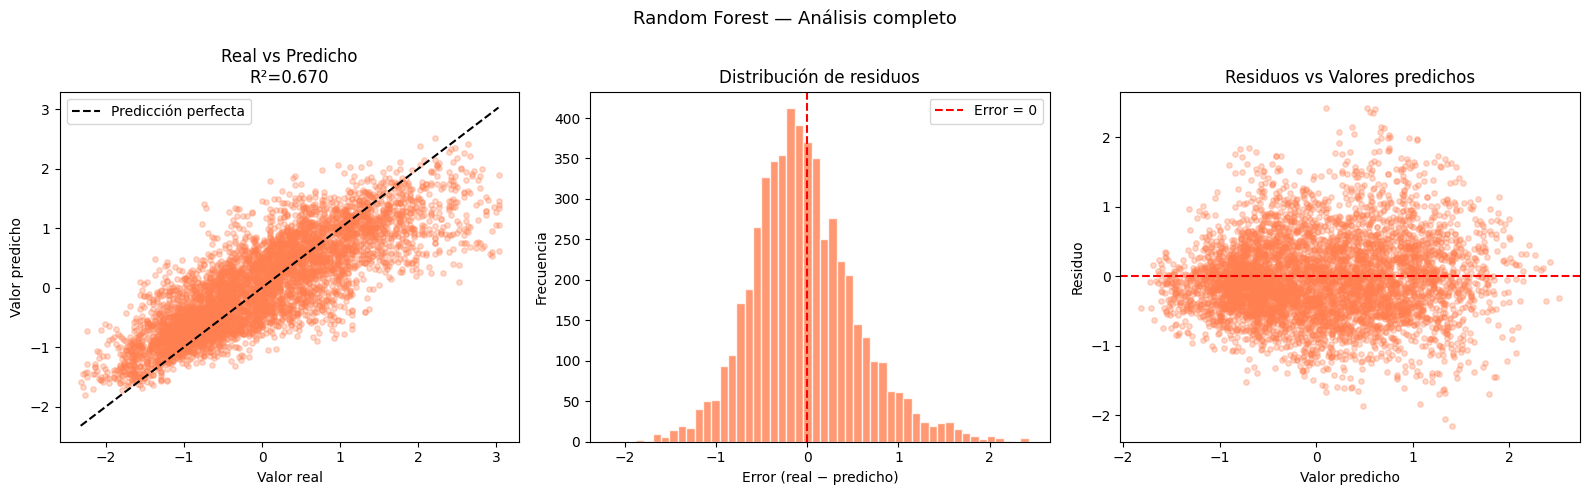

In [109]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Real vs Predicho
axes[0].scatter(y_test, y_pred_mlp, alpha=0.3, s=15, color='coral')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'k--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title(f'Real vs Predicho\nR²={R2_MLP:.3f}')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].legend()

# 2. Distribución de residuos
residuos_rf = y_test - y_pred_mlp
axes[1].hist(residuos_rf, bins=50, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--', label='Error = 0')
axes[1].set_title('Distribución de residuos')
axes[1].set_xlabel('Error (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Residuos vs Predichos
axes[2].scatter(y_pred_mlp, residuos_rf, alpha=0.3, s=15, color='coral')
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_title('Residuos vs Valores predichos')
axes[2].set_xlabel('Valor predicho')
axes[2].set_ylabel('Residuo')

plt.suptitle('Random Forest — Análisis completo', fontsize=13)
plt.tight_layout()
plt.savefig('rf_analisis_completo.png', dpi=150, bbox_inches='tight')
plt.show()

En la grafica de valor real vs predicho podemos ver como los puntos siguen una linea diagonal lo que significa que el modelo si aprendio de las tendencias del dataset pero tambien se puede ver muchos puntos alejados de la diagonal evidenciando una precision no tan buena.
asdasd

En la grafica de distribucion de reciduos podemos ver como el se asemeja a una distribucion normal lo cual es espereable pero vemos como las colas son bastante anchas (+-2.5) indicando que el modelo falla bastante

En el Grafico de los residuos se puede ver como hay una distribucion aleatoria alrededor del cero, pero podemos ver como la varianza aumenta en valores extremoo ya sean altos o bajos.